# Regional LSTM (Precipitation + Temperature) - CAMELS-DE

This code implements a regional Long Short-Term Memory (LSTM) model using precipitation and temperature as input features. The model is trained and evaluated using data from German catchments in the CAMELS-DE dataset.

The workflow includes data loading, sequence generation, model training or loading, hydrological performance evaluation, test-set analysis, and comparison with the published CAMELS-DE benchmarks.

The main workflow is organized as follows:

1. Import the required libraries and connect Google Drive.
2. Load the standardized training, validation, and testing datasets.
3. Define the input variables, sequence length, training parameters, and discharge scaling parameters.
4. Construct catchment-specific input sequences for the regional LSTM.
5. Build and evaluate three LSTM architectures with different numbers of hidden units.
6. Select the best model using validation loss.
7. Evaluate the selected model for all test catchments using NSE, KGE, and PBIAS.
8. Compare the model results with the published CAMELS-DE HBV and LSTM benchmarks.

## Installing and importing the libraries needed

In [ ]:
# In this cell the libraries needed for this notebook are imported.
# Moreover, the connection with Drive is done.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
# Connect this Colab session to Google Drive.
# After authorization, files under /content/drive/MyDrive become accessible.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Loading the data

The standardized input and target datasets for the training, validation, and testing periods are loaded from Google Drive. The column names and first rows are printed to verify that the files were read correctly.

In [ ]:
# Store the common directory once so file paths do not need to be repeated.
base_path = '/content/drive/MyDrive/LSTM_Notebook2/'

# Load standardized dynamic predictors for the training period.
train_input_df  = pd.read_csv(base_path + 'Training_Features_Standardized_INPUT.csv')

# Load the corresponding standardized discharge targets for training.
train_target_df = pd.read_csv(base_path + 'Training_Features_Standardized_TARGET.csv')


# Load validation predictors used to monitor generalization during model selection.
val_input_df    = pd.read_csv(base_path + 'Validation_Features_Standardized_INPUT.csv')

# Load validation targets. These values do not update the model weights.
val_target_df   = pd.read_csv(base_path + 'Validation_Features_Standardized_TARGET.csv')


# Load test predictors reserved for the final evaluation.
test_input_df   = pd.read_csv(base_path + 'Testing_Features_Standardized_INPUT.csv')

# Load test targets. They must remain unused during hyperparameter selection.
test_target_df  = pd.read_csv(base_path + 'Testing_Features_Standardized_TARGET.csv')

print(train_input_df.columns.tolist())
print(train_input_df.head())
print(train_target_df.columns.tolist())
print(train_target_df.head())

['Date', 'Catchment_ID', 'P', 'T']
         Date                            Catchment_ID         P         T
0  1951-01-01  CAMELS_DE_hydromet_timeseries_DEA10000  0.567746 -1.241722
1  1951-01-02  CAMELS_DE_hydromet_timeseries_DEA10000  0.668648 -1.129972
2  1951-01-03  CAMELS_DE_hydromet_timeseries_DEA10000 -0.221303 -1.241722
3  1951-01-04  CAMELS_DE_hydromet_timeseries_DEA10000  0.487025 -1.201331
4  1951-01-05  CAMELS_DE_hydromet_timeseries_DEA10000  0.273114 -0.716631
['Date', 'Catchment_ID', 'Q']
         Date                            Catchment_ID         Q
0  1951-01-01  CAMELS_DE_hydromet_timeseries_DEA10000 -0.209211
1  1951-01-02  CAMELS_DE_hydromet_timeseries_DEA10000 -0.269561
2  1951-01-03  CAMELS_DE_hydromet_timeseries_DEA10000 -0.329910
3  1951-01-04  CAMELS_DE_hydromet_timeseries_DEA10000 -0.354050
4  1951-01-05  CAMELS_DE_hydromet_timeseries_DEA10000 -0.203176


## 2. General configuration

This section defines the predictor variables, target variable, catchment identifier, LSTM sequence length, batch size, maximum number of epochs, and the number of batches used during training and validation. It also defines the parameters required to convert standardized discharge values back to their original units and creates the output directory for the results.

In [ ]:
# Select precipitation and temperature as the only dynamic predictors.
FEATURE_COLS   = ['P', 'T']     # Input variables: precipitation and temperature
# Define discharge Q as the continuous variable to be predicted.
TARGET_COL     = 'Q'
CATCHMENT_COL  = 'Catchment_ID'
# Get the number of input features automatically from FEATURE_COLS.
N_FEATURES     = len(FEATURE_COLS)
# Use one full year of previous daily observations for each prediction.
# This long window allows the LSTM to learn seasonal and delayed hydrological responses.
WINDOW           = 365   # Number of previous days in each sequence
# Process 128 sequences before calculating one optimizer update.
BATCH_SIZE       = 128
EPOCHS           = 50    # Maximum number of training epochs
# Because the dataset is generated continuously, explicitly define how many batches form one epoch.
# Define the number of training batches processed in one epoch because the generator is infinite.
STEPS_PER_EPOCH  = 1000
# Evaluate a fixed number of validation batches after each training epoch.
VALIDATION_STEPS = 100

# Parameters used to convert standardized Q back to its original scale.
# These values are the training-set statistics used during preprocessing
# This procedure is explain in (Notebook 1)
mean_Q = 1.10666492
std_Q  = 1.65701115

print(f"Q Mean (mean_Q): {mean_Q}")
print(f"Q Standard Deviation (std_Q): {std_Q}")

# Create the folder used to save models, tables, and figures.
results_path = base_path + 'results/'
os.makedirs(results_path, exist_ok=True)
print(f"Results output path defined: {results_path}")

Q Mean (mean_Q): 1.10666492
Q Standard Deviation (std_Q): 1.65701115
Results output path defined: /content/drive/MyDrive/LSTM_Notebook2/results/


## 3. Constructing the input feature matrix

The LSTM requires a three-dimensional input structure with the dimensions **samples × time steps × features**. Instead of constructing the complete matrix in memory, catchment-specific arrays and a TensorFlow generator are used to create 365-day sequences dynamically. This prevents sequences from crossing catchment boundaries and reduces memory requirements.

In [ ]:
# Build 3D sequences as [samples, time steps, features].
# Windows are generated by catchment to avoid mixing different basins.

# Convert each catchment into a pair of NumPy arrays and store them in a dictionary.
# Precomputing these arrays avoids repeatedly filtering pandas DataFrames during training.
def build_catchment_arrays(input_df, target_df, feature_cols, target_col, catchment_col):
    """Extract and store the P, T, and Q arrays for each catchment once."""
    arrays = {}
    # Process one catchment at a time, preserving the original row order.
    for cid, group in input_df.groupby(catchment_col, sort=False):
        x = group[feature_cols].to_numpy(dtype=np.float32)
        y = target_df.loc[target_df[catchment_col] == cid, target_col].to_numpy(dtype=np.float32)
        # Use the shorter length if input and target tables differ slightly, ensuring aligned arrays.
        n = min(len(x), len(y))
        # Save aligned predictors and targets under the catchment identifier.
        arrays[cid] = (x[:n], y[:n])
    return arrays

# Import a vectorized NumPy utility that creates overlapping windows without a slow Python loop.
from numpy.lib.stride_tricks import sliding_window_view

# Produces batches of sequences indefinitely so TensorFlow can stream data during training.
# The generator produces the same type of windows as a loop but uses vectorized slicing for speed.
def sequence_generator(catchment_arrays, window):
    """
    Same windows as before, but built with vectorized numpy slicing
    instead of a per-day Python loop (much faster, same data).
    """
    catchments = list(catchment_arrays.keys())

    while True:
        # Shuffle catchment order at the start of every generator pass (epoch)
        # Randomize catchment order at the beginning of each generator pass.
        # This changes the batch order while preserving the chronological order within each sequence.
        np.random.shuffle(catchments)

        for cid in catchments:
            X, Q = catchment_arrays[cid]

            # Skip catchments that do not contain enough observations to form at least one input-target pair.
            if len(X) <= window:
                continue

            # Build all sliding windows for this catchment at once:
            # shape (n_windows, n_features, window), then transpose to
            # (n_windows, window, n_features), which is what the LSTM expects
            # Create all overlapping 365-day predictor windows for the current catchment.
            X_windows = sliding_window_view(X, window_shape=window, axis=0)
            X_windows = X_windows.transpose(0, 2, 1)

            # sliding_window_view produces one extra window at the end that
            # has no valid "next day" target, then drop it
            X_windows = X_windows[:-1]
            Q_targets = Q[window:]

            # Keep only windows/targets with no missing values
            valid_mask = ~(np.isnan(X_windows).any(axis=(1, 2)) | np.isnan(Q_targets))

            for x_window, q_target in zip(X_windows[valid_mask], Q_targets[valid_mask]):
                yield (x_window, q_target)


# Pre-extract the per-catchment arrays once for each split
# Precompute catchment arrays for the training split.
train_arrays = build_catchment_arrays(train_input_df, train_target_df, FEATURE_COLS, TARGET_COL, CATCHMENT_COL)
val_arrays   = build_catchment_arrays(val_input_df,   val_target_df,   FEATURE_COLS, TARGET_COL, CATCHMENT_COL)
test_arrays  = build_catchment_arrays(test_input_df,  test_target_df,  FEATURE_COLS, TARGET_COL, CATCHMENT_COL)

# Wrap the generator in a tf.data.Dataset, so Keras can consume it directly
# Wrap the Python generator in a TensorFlow Dataset for efficient model training.
train_dataset = tf.data.Dataset.from_generator(
    lambda: sequence_generator(train_arrays, WINDOW),
    output_signature=(
        tf.TensorSpec(shape=(WINDOW, N_FEATURES), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.float32)
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: sequence_generator(val_arrays, WINDOW),
    output_signature=(
        tf.TensorSpec(shape=(WINDOW, N_FEATURES), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.float32)
    )
)

# Shuffle, batch and prefetch for efficient training
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## 4. Building and training the LSTM

Three LSTM architectures are considered, containing 64, 96, and 128 hidden units. Each model uses a hyperbolic tangent activation in the recurrent layer and a linear Dense output layer for discharge regression. The models are trained with the Adam optimizer and mean squared error loss. Early stopping monitors validation loss and restores the weights from the best epoch.

The `RETRAIN_MODELS` switch determines whether the architectures are trained again or whether previously saved models and loss curves are loaded. Loading the saved models ensures that the remaining analyses use the exact weights from the selected successful training run.

RETRAIN_MODELS = False -> cargando modelos y curvas de loss de la corrida ya guardada en results_path (no se reentrena).


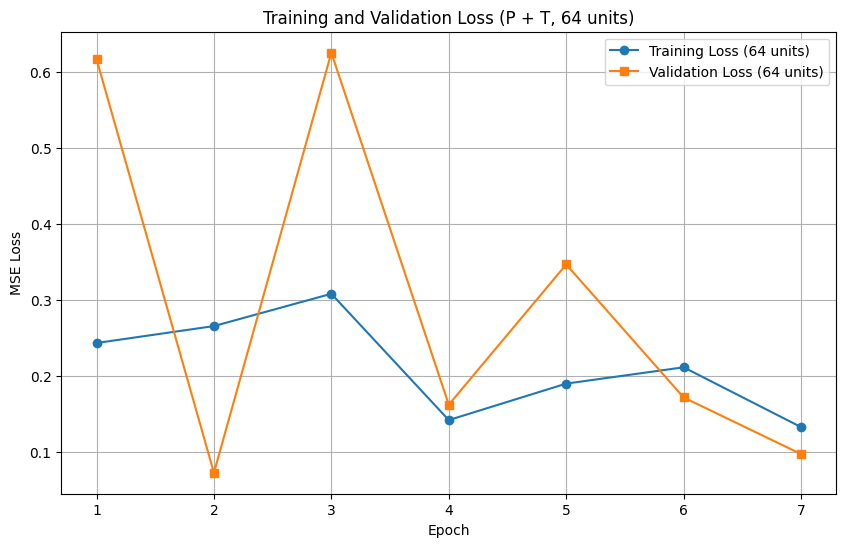

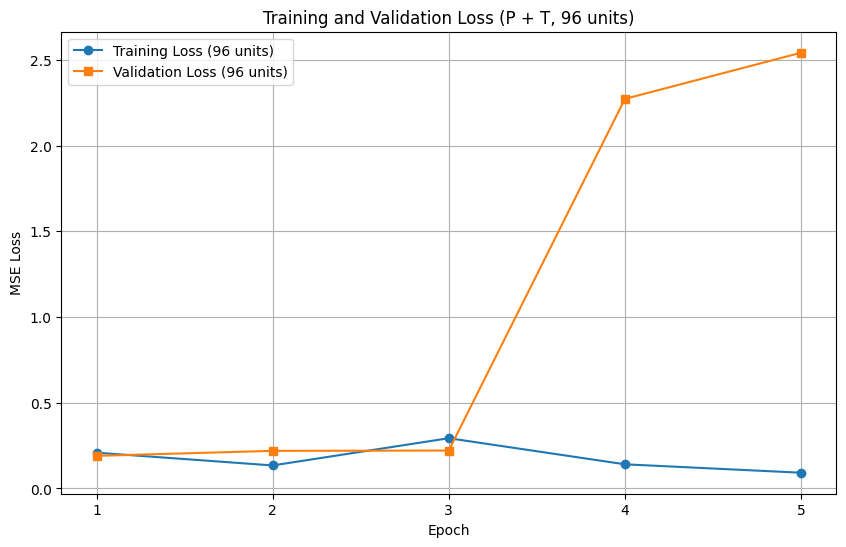

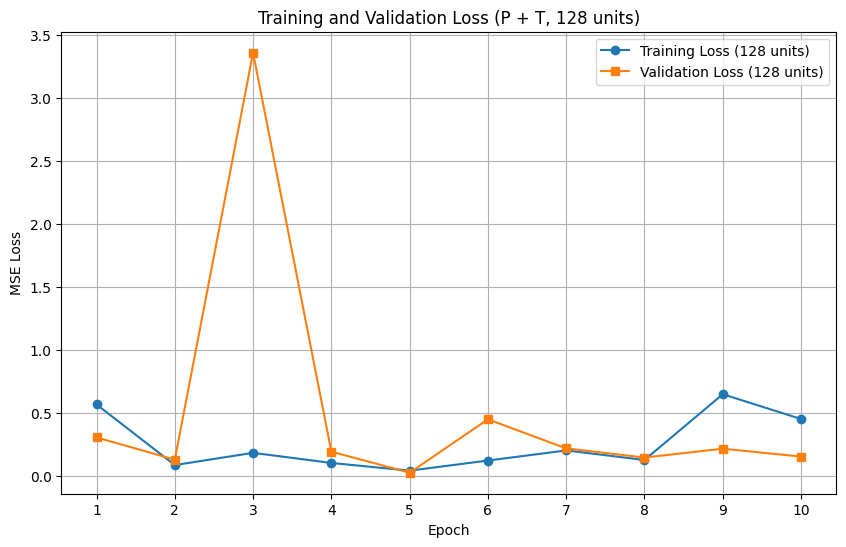

Minimum Validation Loss for 64 units:  0.0730
Minimum Validation Loss for 96 units:  0.1903
Minimum Validation Loss for 128 units: 0.0285

El modelo con mejor desempeno en validacion es: 128 units (Validation Loss: 0.0285)


In [ ]:
# Create a many-to-one LSTM model with a configurable number of hidden units.
# Many-to-one means that a sequence of 365 days produces one discharge prediction.
def build_model(hidden_units):
    # Suggested architecture (Step 7): a single LSTM layer followed by one
    # linear Dense layer that predicts Q(t).
    # Hidden_units (64, 96, 128)
    model = tf.keras.Sequential([
        # Tell the network to expect WINDOW time steps and N_FEATURES variables per sample.
        tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
        # The LSTM learns temporal dependencies and summarizes the full sequence in its final hidden state.
        # Tanh is the standard candidate-state activation used inside an LSTM.
        tf.keras.layers.LSTM(hidden_units, activation='tanh', return_sequences=False),
        # Map the final LSTM representation to one unrestricted continuous discharge value.
        tf.keras.layers.Dense(1, activation='linear')
    ])

    model.compile(
        # Adam adapts the learning rate for each parameter; 0.001 is a common stable starting value.
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        # Minimize mean squared error, which penalizes large prediction errors more strongly.
        loss='mse',
        metrics=['mae']
    )
    return model


# Early stopping on validation loss
# Monitor validation loss and stop when it no longer improves.
# restore_best_weights=True returns the model to the epoch with the lowest validation loss.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# Train one architecture, save the model, and store its learning curves.
# The tag identifies the experiment in filenames and summary tables.
def train_and_log(hidden_units, tag):
    """Train one model and save the model weights and loss curves in results_path."""
    model = build_model(hidden_units)

    # Fit the network using streamed training batches and evaluate validation batches after every epoch.
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        # Define the number of training batches processed in one epoch because the generator is infinite.
        steps_per_epoch=STEPS_PER_EPOCH,
        # Evaluate a fixed number of validation batches after each training epoch.
        validation_steps=VALIDATION_STEPS,
        callbacks=[early_stop],
        verbose=1
    )

    # Save the complete trained model so it can be reloaded without retraining.
    model.save(results_path + f'LSTM{tag}_P_T.keras')

    # Extract the loss values recorded during training for convergence analysis.
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    losses = pd.DataFrame({'train_loss': train_loss, 'val_loss': val_loss})
    losses.to_excel(results_path + f'Loss_curves_P_T_{tag}.xlsx', index=False)

    epochs_range = range(1, len(train_loss) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_loss, marker='o', label=f'Training Loss ({tag} units)')
    plt.plot(epochs_range, val_loss, marker='s', label=f'Validation Loss ({tag} units)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'Training and Validation Loss (P + T, {tag} units)')
    plt.xticks(epochs_range)
    plt.grid(True)
    plt.legend()
    plt.savefig(results_path + f'Losses_P_T_{tag}.png', dpi=600, format='png')
    plt.show()

    return model, history


# Set True to train all architectures or False to load the saved models.
#
# TRAIN_MODELS = True
# Runs train_and_log() for all three architectures,
#                  it generates LSTM64_P_T.keras, LSTM96_P_T.keras, LSTM128_P_T.keras,
#                  and their corresponding Loss_curves_P_T_*.xlsx files
#                  stored in results_path.
#
# RETRAIN_MODELS = False
#                  Does not train the models because stochastic training
#                  can produce slightly different results in each run.
#                  Instead, it loads the previously saved model files
#
#                  Figures and performance metrics are based on exactly
#                  the same trained weights if saved models are used.
RETRAIN_MODELS = False

if RETRAIN_MODELS:
    # Train the three required LSTM architectures.
    model64,  history64  = train_and_log(64,  '64')
    model96,  history96  = train_and_log(96,  '96')
    model128, history128 = train_and_log(128, '128')

    val_loss_64  = min(history64.history['val_loss'])
    val_loss_96  = min(history96.history['val_loss'])
    val_loss_128 = min(history128.history['val_loss'])

else:
    print("RETRAIN_MODELS = False, then the previously saved model files are loaded")

    model64  = tf.keras.models.load_model(results_path + 'LSTM64_P_T.keras')
    model96  = tf.keras.models.load_model(results_path + 'LSTM96_P_T.keras')
    model128 = tf.keras.models.load_model(results_path + 'LSTM128_P_T.keras')

    losses_64  = pd.read_excel(results_path + 'Loss_curves_P_T_64.xlsx')
    losses_96  = pd.read_excel(results_path + 'Loss_curves_P_T_96.xlsx')
    losses_128 = pd.read_excel(results_path + 'Loss_curves_P_T_128.xlsx')

    val_loss_64  = losses_64['val_loss'].min()
    val_loss_96  = losses_96['val_loss'].min()
    val_loss_128 = losses_128['val_loss'].min()

        # Reproduce the saved training and validation loss curves.
    for tag, losses in [('64', losses_64), ('96', losses_96), ('128', losses_128)]:
        epochs_range = range(1, len(losses) + 1)
        plt.figure(figsize=(10, 6))
        plt.plot(epochs_range, losses['train_loss'], marker='o', label=f'Training Loss ({tag} units)')
        plt.plot(epochs_range, losses['val_loss'], marker='s', label=f'Validation Loss ({tag} units)')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.title(f'Training and Validation Loss (P + T, {tag} units)')
        plt.xticks(epochs_range)
        plt.grid(True)
        plt.legend()
        plt.show()

# Select the architecture with the lowest validation loss.
# The same selection logic is used whether the models were trained or loaded.
print(f"Minimum Validation Loss for 64 units:  {val_loss_64:.4f}")
print(f"Minimum Validation Loss for 96 units:  {val_loss_96:.4f}")
print(f"Minimum Validation Loss for 128 units: {val_loss_128:.4f}")

models = {'64': model64, '96': model96, '128': model128}
val_losses = {'64': val_loss_64, '96': val_loss_96, '128': val_loss_128}

best_tag = min(val_losses, key=val_losses.get)
best_model = models[best_tag]

print(f"\nThe model with the best performance in validation is: {best_tag} units "
      f"(Validation Loss: {val_losses[best_tag]:.4f})")


## 5. Hydrological performance metrics

The model is evaluated using three common hydrological metrics:

- **Nash-Sutcliffe Efficiency (NSE):** measures predictive skill relative to the mean observed discharge. Defined in the range (-inf,1], with 1 being perfect model performance. It is sensitive to extreme events.
- **Kling-Gupta Efficiency (KGE):** combines correlation, bias, and variability components. It is more balanced than NSE.
- **Percent Bias (PBIAS):** measures systematic overestimation or underestimation of total discharge.
PBIAS=0 perfect, PBIAS>0 model overestimation, PBIAS< 0 model underestimation

The prediction function creates all valid 365-day windows for one catchment, generates standardized predictions, and optionally transforms both predictions and observations back to the original discharge scale.

In [ ]:
def NSE(obs, sim):
    # Nash-Sutcliffe Efficiency: 1 = perfect fit, 0 = as good as the mean of
    # the observations, <0 = worse than just predicting the mean.
    obs, sim = np.asarray(obs), np.asarray(sim)
    mask = (~np.isnan(obs)) & (~np.isnan(sim))
    obs, sim = obs[mask], sim[mask]
    if len(obs) == 0:
        return np.nan
    denominator = np.sum((obs - np.mean(obs)) ** 2)
    if denominator == 0:
        return np.nan
    numerator = np.sum((obs - sim) ** 2)
    return 1 - numerator / denominator


def KGE(obs, sim):
    # Kling-Gupta Efficiency: combines correlation (r), bias ratio (beta),
    # and variability ratio (gamma) into a single score (1 = perfect fit).
    obs, sim = np.asarray(obs), np.asarray(sim)
    mask = (~np.isnan(obs)) & (~np.isnan(sim))
    obs, sim = obs[mask], sim[mask]
    if len(obs) == 0 or np.mean(obs) == 0 or np.std(obs) == 0:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    beta = np.mean(sim) / np.mean(obs)
    gamma = (np.std(sim) / np.mean(sim)) / (np.std(obs) / np.mean(obs))
    return 1 - np.sqrt((r - 1) ** 2 + (beta - 1) ** 2 + (gamma - 1) ** 2)


def PBIAS(obs, sim):
    # Percent Bias: positive = model overestimates on average,
    # negative = model underestimates on average.
    obs, sim = np.asarray(obs), np.asarray(sim)
    mask = (~np.isnan(obs)) & (~np.isnan(sim))
    obs, sim = obs[mask], sim[mask]
    if len(obs) == 0 or np.sum(obs) == 0:
        return np.nan
    return 100 * np.sum(sim - obs) / np.sum(obs)


def predict_catchment(model, X, Q, window=WINDOW, mean_q=0.0, std_q=1.0, inverse_standardize=False):
    """
    X: array (n_days, n_features) with the (standardized) P and T of one catchment
    Q: array (n_days,) with the (standardized) observed discharge of that catchment
    """
    X_windows, observations = [], []

    for i in range(window, len(X)):
        x_window = X[i - window:i, :]
        if np.isnan(x_window).any() or np.isnan(Q[i]):
            continue
        X_windows.append(x_window)
        observations.append(Q[i])

    if len(X_windows) == 0:
        return np.array([]), np.array([])

    X_windows = np.asarray(X_windows, dtype=np.float32)
    predictions = model.predict(X_windows, batch_size=1024, verbose=0).flatten()
    observations = np.asarray(observations)

    # Convert observations and predictions back to the original Q scale.
    if inverse_standardize:
        predictions = (predictions * std_q) + mean_q
        observations = (observations * std_q) + mean_q

    return observations, predictions

## 6. Evaluating the model on the test set

The selected model is evaluated independently for every catchment in the test dataset. NSE, KGE, and PBIAS are calculated using discharge values converted back to their original units. The catchment-level results are saved to Excel, and the overall performance is summarized using an NSE boxplot, an example hydrograph, and an empirical cumulative distribution function.

Evaluating 492 catchments with the best model (128 units)...

25/492 completed
50/492 completed
75/492 completed
100/492 completed
125/492 completed
150/492 completed
175/492 completed
200/492 completed
225/492 completed
250/492 completed
275/492 completed
300/492 completed
325/492 completed
350/492 completed
375/492 completed
400/492 completed
425/492 completed
450/492 completed
475/492 completed
                                Catchment  Samples       NSE       KGE  \
0  CAMELS_DE_hydromet_timeseries_DEA10000     5114  0.586998  0.546894   
1  CAMELS_DE_hydromet_timeseries_DEA10040     5114  0.743721  0.634810   
2  CAMELS_DE_hydromet_timeseries_DEA10060     5114  0.681524  0.630861   
3  CAMELS_DE_hydromet_timeseries_DEA10100     5100  0.504759  0.469300   
4  CAMELS_DE_hydromet_timeseries_DEA10210     4839  0.663390  0.637196   

       PBIAS  
0 -32.240479  
1  -6.407870  
2 -21.688082  
3 -38.270481  
4 -33.416943  
count    492.000000
mean       0.358849
std        1.146404
min 

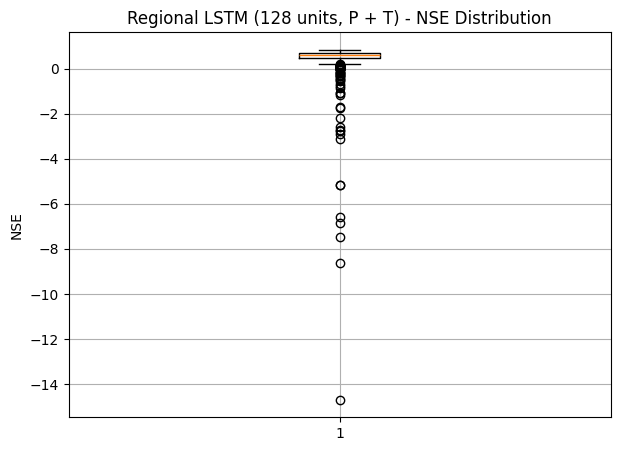

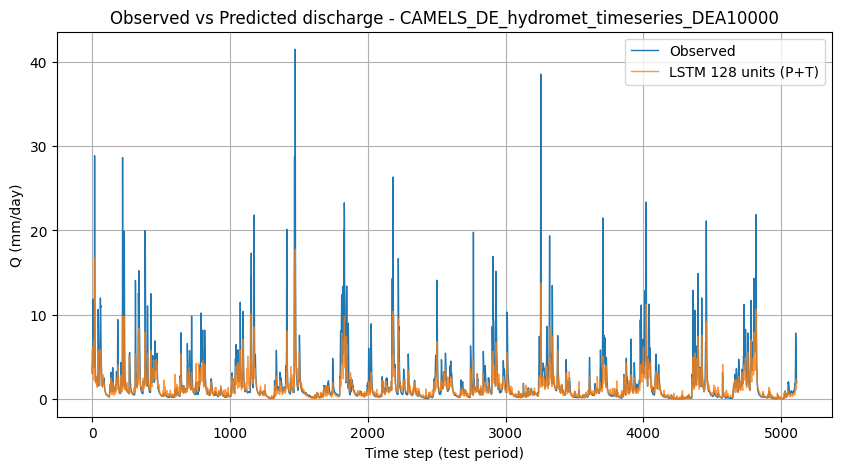

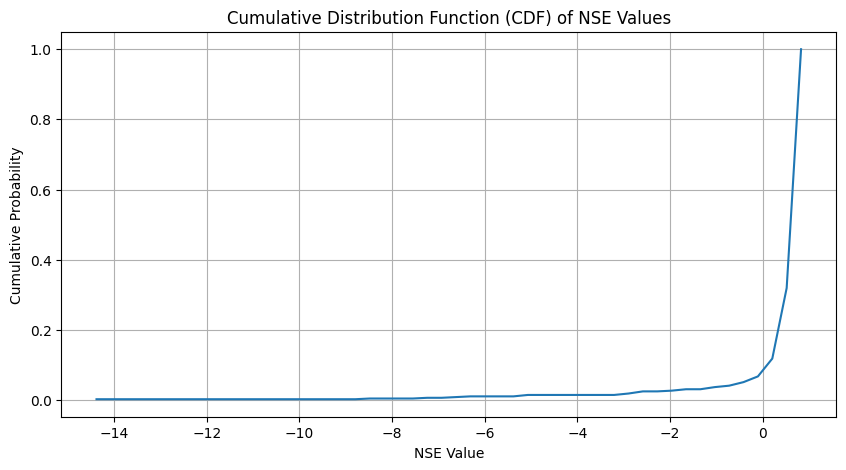

Todos los graficos y el Excel de resultados se guardaron en: /content/drive/MyDrive/LSTM_Notebook2/results/


In [ ]:
results_best_model = []
catchments = list(test_arrays.keys())

print(f"Evaluating {len(catchments)} catchments with the best model ({best_tag} units)...\n")

# Loop over every catchment in the test set and compute NSE/KGE/PBIAS,
# in real units (mm/day), for the selected best model
# Iterate through all test catchments and calculate metrics separately for each basin.
for n, cid in enumerate(catchments):
    X_c, Q_c = test_arrays[cid]

    obs, pred = predict_catchment(
        best_model, X_c, Q_c, window=WINDOW,
        mean_q=mean_Q, std_q=std_Q, inverse_standardize=True
    )

    if len(obs) == 0:
        continue

    # Store the catchment identifier, sample count, and three hydrological metrics.
    results_best_model.append([
        cid,
        len(obs),
        NSE(obs, pred),
        KGE(obs, pred),
        PBIAS(obs, pred)
    ])

    if (n + 1) % 25 == 0:
        print(f"{n + 1}/{len(catchments)} completed")

# Convert the collected evaluation results into a table for analysis and export.
results_best_model_df = pd.DataFrame(
    results_best_model,
    columns=['Catchment', 'Samples', 'NSE', 'KGE', 'PBIAS']
)

print(results_best_model_df.head())
print(results_best_model_df['NSE'].describe())

# Save catchment-level performance so it can be inspected outside the notebook.
results_best_model_df.to_excel(results_path + 'NSE_best_model.xlsx', index=False)
print("Evaluation results for the best model saved to 'NSE_best_model.xlsx'.")

#
# Overall performance summary: boxplot, example hydrograph, and CDF
#
plt.figure(figsize=(7, 5))
# Compare score distributions rather than only comparing mean values.
# The median, spread, and outliers show how consistently each model performs across catchments.
plt.boxplot(results_best_model_df['NSE'].dropna())
plt.ylabel('NSE')
plt.title(f'Regional LSTM ({best_tag} units, P + T) - NSE Distribution')
plt.grid(True)
plt.savefig(results_path + 'NSE_boxplot_best_model.png', dpi=600, format='png')
plt.show()

example_cid = catchments[0]
X_ex, Q_ex = test_arrays[example_cid]
obs_ex, pred_ex = predict_catchment(
    best_model, X_ex, Q_ex, window=WINDOW,
    mean_q=mean_Q, std_q=std_Q, inverse_standardize=True
)

plt.figure(figsize=(10, 5))
plt.plot(obs_ex, label='Observed', linewidth=1)
plt.plot(pred_ex, label=f'LSTM {best_tag} units (P+T)', linewidth=1, alpha=0.8)
plt.xlabel('Time step (test period)')
plt.ylabel('Q (mm/day)')
plt.title(f'Observed vs Predicted discharge - {example_cid}')
plt.legend()
plt.grid(True)
plt.savefig(results_path + 'Hydrograph_example_best_model.png', dpi=600, format='png')
plt.show()

n_bins = 50
nse_data = results_best_model_df['NSE'].dropna()
count, bin_edges = np.histogram(nse_data, bins=n_bins, density=True)
cdf = np.cumsum(count * np.diff(bin_edges))

plt.figure(figsize=(10, 5))
plt.plot(bin_edges[1:], cdf)
plt.xlabel('NSE Value')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function (CDF) of NSE Values')
plt.grid(True)
plt.savefig(results_path + 'NSE_cdf_best_model.png', dpi=600, format='png')
plt.show()

print("All graphs and excel files are saved in the path:", results_path)

## 7. Comparison against the published CAMELS-DE benchmark (Loritz et al., 2024)

The catchment-level NSE values produced by the regional LSTM are matched with the published CAMELS-DE benchmark results using the gauge identifier. The comparison includes the model developed in this notebook, the HBV benchmark, and the published CAMELS-DE LSTM benchmark. The combined results are saved to Excel and visualized with a comparative boxplot.

                                Catchment  NSE_own_model  NSE_lstm  NSE_hbv
0  CAMELS_DE_hydromet_timeseries_DEA10000       0.586998     0.940    0.870
1  CAMELS_DE_hydromet_timeseries_DEA10040       0.743721     0.944    0.831
2  CAMELS_DE_hydromet_timeseries_DEA10060       0.681524     0.928    0.867
3  CAMELS_DE_hydromet_timeseries_DEA10100       0.504759     0.935    0.840
4  CAMELS_DE_hydromet_timeseries_DEA10210       0.663390     0.949    0.873
       NSE_own_model    NSE_lstm     NSE_hbv
count     492.000000  492.000000  492.000000
mean        0.358849    0.832289    0.710774
std         1.146404    0.121492    0.150901
min       -14.691639   -0.267000   -0.447000
25%         0.477483    0.808750    0.657750
50%         0.599130    0.864000    0.745000
75%         0.667248    0.899000    0.808000
max         0.830722    0.961000    0.919000


/tmp/ipykernel_452/2557647310.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


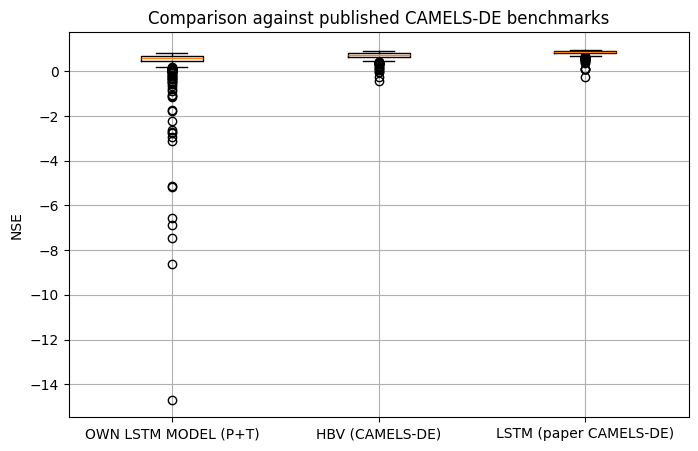

In [ ]:
#
# Load and read published CAMELS-DE benchmarks results.
#
benchmark_df = pd.read_csv(base_path + 'CAMELS_DE_simulation_benchmark.csv')

# Extract the gauge ID used to match both datasets.
# Extract the numerical gauge identifier from the catchment name.
results_best_model_df['gauge_id'] = results_best_model_df['Catchment'].str.split('_').str[-1]

# Join the own-model results with published scores using the common gauge ID.
comparison_df = results_best_model_df.merge(
    benchmark_df[['gauge_id', 'NSE_lstm', 'NSE_hbv']],
    on='gauge_id', how='left'
)

comparison_df = comparison_df.rename(columns={'NSE': 'NSE_own_model'})

print(comparison_df[['Catchment', 'NSE_own_model', 'NSE_lstm', 'NSE_hbv']].head())
print(comparison_df[['NSE_own_model', 'NSE_lstm', 'NSE_hbv']].describe())

comparison_df.to_excel(results_path + 'NSE_comparison_vs_benchmark.xlsx', index=False)

#
# Compare the NSE distributions of the three models.
#
plt.figure(figsize=(8, 5))
# Compare score distributions rather than only comparing mean values.
# The median, spread, and outliers show how consistently each model performs across catchments.
plt.boxplot(
    [comparison_df['NSE_own_model'].dropna(),
     comparison_df['NSE_hbv'].dropna(),
     comparison_df['NSE_lstm'].dropna()],
    labels=['OWN LSTM MODEL (P+T)', 'HBV (CAMELS-DE)', 'LSTM (paper CAMELS-DE)']
)
plt.ylabel('NSE')
plt.title('Comparison against published CAMELS-DE benchmarks')
plt.grid(True)
plt.savefig(results_path + 'NSE_comparison_boxplot.png', dpi=600, format='png')
plt.show()